# Homework 4 analysis

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'

import wrds
import math
import numpy as np
import wget, shutil

from matplotlib import pyplot as plt
import statsmodels.api as sm
def ols_with_constant(y,x): return sm.OLS(y, sm.add_constant(x))
from scipy.optimize import minimize

from utils.french_portfolios import get_French_portfolios_monthly

In [2]:
# Set start and end years (as strings)
startyear = '1971'
endyear = '2000'

In [3]:
# Download data from WRDS
conn = wrds.Connection(wrds_username='wmann')
FF3F = conn.get_table(library='ff_all',table='factors_monthly',coerce_float=True)
FF_portfolios = conn.get_table(library='ff_all',table='portfolios',coerce_float=True)
conn.close()

# Portfolios used for factor returns
FF_portfolios['month'] = pd.to_datetime(FF_portfolios['date'],format="%Y-%m-%d",exact=True).dt.to_period('M')
FF_portfolios.set_index('month',inplace=True)
FF_portfolios = FF_portfolios[startyear:endyear]

# Risk-free and market returns
FF3F['month'] = pd.to_datetime(FF3F['date']).dt.to_period('M')
FF3F = FF3F[['month','rf','mktrf','hml','smb']].set_index('month')
FF3F = FF3F[startyear:endyear]
rf = FF3F['rf']
mktrf = FF3F['mktrf']

Loading library list...
Done


In [4]:
# Download Ken French's historical data on 10 portfolios formed on book-to-market ("value")
value_portfolios = get_French_portfolios_monthly("value")
value_portfolios = value_portfolios.loc[startyear:endyear]
value_portfolios.rename(columns={'Lo 30':'lo30','Hi 30':'hi30'},inplace=True)
lo30bm_ex = ( value_portfolios['lo30'] - rf ).rename('lo30bm_ex')
hi30bm_ex = ( value_portfolios['hi30'] - rf ).rename('hi30bm_ex')

100% [........................................................] 217135 / 217135

In [5]:
# Download Ken French's historical data on 10 portfolios formed on market capitalization ("size")
size_portfolios = get_French_portfolios_monthly("size")
size_portfolios = size_portfolios.loc[startyear:endyear]
size_portfolios.rename(columns={'Lo 30':'lo30','Hi 30':'hi30'},inplace=True)
lo30me_ex = ( size_portfolios['lo30'] - rf ).rename('lo30me_ex')
hi30me_ex = ( size_portfolios['hi30'] - rf ).rename('hi30me_ex')

100% [........................................................] 198802 / 198802

In [6]:
hi30bm_bal = (FF_portfolios['smhi_vwret'] + FF_portfolios['bihi_vwret'])/2
hi30bm_bal_ex = (hi30bm_bal - rf).rename('hi30bm_bal_ex')
lo30bm_bal = (FF_portfolios['smlo_vwret'] + FF_portfolios['bilo_vwret'])/2
lo30bm_bal_ex = (lo30bm_bal - rf).rename('lo30bm_bal_ex')

In [7]:
# # Save to Excel
# HW_data_path = "Homework 4 data.xlsx"
# if os.path.exists(HW_data_path): os.remove(HW_data_path)
# writer = pd.ExcelWriter(HW_data_path, engine='xlsxwriter', datetime_format= "yyyy-mm")
# pd.concat([mktrf,hi30bm_ex,lo30bm_ex,lo30me_ex,hi30me_ex,hi30bm_bal_ex,lo30bm_bal_ex],axis=1).to_excel(
#     writer,
#     sheet_name='Data',
#     index_label='Month',
#     columns=['mktrf','hi30bm_ex','lo30bm_ex','lo30me_ex','hi30me_ex','hi30bm_bal_ex','lo30bm_bal_ex'],
#     header=['Market','Value','Growth','Small','Large','Value - balanced','Growth - balanced']
# )
# writer.close()

Analysis

1. Show that the value portfolio from our in-class example has a lower alpha, but a higher information ratio, than the dollar-neutral strategy that we looked at. Based on these patterns, would an index investor be more interested in the dollar-neutral strategy or a simpler long-only value strategy?

In [8]:
reg = ols_with_constant(hi30bm_ex,mktrf).fit()
print(f"Value portfolio alpha: {100*reg.params.iloc[0] :.2f}%")
print(f"Value portfolio IR: {reg.params.iloc[0] / reg.resid.std() :.5f}")

Value portfolio alpha: 0.39%
Value portfolio IR: 0.18817


In [9]:
reg = ols_with_constant(hi30bm_ex - lo30bm_ex,mktrf).fit()
print(f"Dollar-neutral portfolio alpha: {100*reg.params.iloc[0] :.2f}%")
print(f"Dollar-neutral portfolio IR: {reg.params.iloc[0] / reg.resid.std() :.5f}")

Dollar-neutral portfolio alpha: 0.48%
Dollar-neutral portfolio IR: 0.16389


The right way to assess these strategies is with the information ratio. Since the long-only portfolio has a higher information ratio than the dollar-neutral portfolio, that is the one the investor would want to use alongside an index fund.

2. Show that a strategy of short-selling growth stocks had an alpha of close to zero. Why does that help explain what you found in #1? 

In [29]:
reg = ols_with_constant(-lo30bm_ex,mktrf).fit()
print(f"Alpha from short-selling growth stocks: {100*reg.params.iloc[0] :.2f}%")
print(f"Short portfolio IR: {reg.params.iloc[0] / reg.resid.std() :.5f}")

Alpha from short-selling growth stocks: 0.08%
Short portfolio IR: 0.07865


So the short-selling in the dollar-neutral strategy just adds volatility without much return.
The extra volatility hurts the IR compared to a simpler approach of just holding value stocks.

3. Calculate the correlation of the excess returns on the growth portfolio, and the large-cap portfolio. Why is it not surprising that this number is extremely high? (Think about what defines a growth stock, and what defines a large-cap stock.)

In [11]:
corr = np.corrcoef([ lo30bm_ex , hi30me_ex ])[0,1]
print(f"Correlation between large-cap and growth returns: {100*corr :.2f}%")

Correlation between large-cap and growth returns: 97.40%


This makes sense, because a growth stock is one with a high price relative to fundamentals, and this would tend to be larger cap stocks in general though they aren’t exactly the same thing. Since each portfolio is value-weighted, there will be a lot of large cap stocks in common between the two portfolios and then they will completely drive the returns, which will end up looking the same.

4. Show that a strategy of short-selling large-cap stocks had slightly negative alpha. Based on this, and the other evidence so far, why might it be worth looking into a dollar-neutral value-minus-growth strategy that tries to “balance” the long and short portfolios by market cap?

In [12]:
reg = ols_with_constant( -hi30me_ex , mktrf ).fit()
print(f"Alpha from short-selling large-cap: {100*reg.params.iloc[0] :.2f}%")

Alpha from short-selling large-cap: -0.01%


The short growth position in our original dollar-neutral strategy ends up being mainly a bet against large-cap stocks, which has not been a good bet historically. But maybe if we "balance" the portfolio, we can end up with a bet against growth stocks that is different from a bet against large-cap stocks.

5. Now look at the size-balanced portfolio returns in Columns H and I. Show that there was positive alpha to short-selling the size-balanced growth portfolio. Show that the alpha and information ratio of the size-balanced dollar-neutral strategy are both higher than the alpha and information ratio of the size-balance value strategy alone, and also higher than the values we found in #1. From all this evidence, what do we learn about the best way to implement a dollar-neutral value strategy in practice?

In [13]:
reg = ols_with_constant( -lo30bm_bal_ex , mktrf ).fit()
print(f"Alpha from short-selling size-balanced growth: {100*reg.params.iloc[0] :.2f}%")

Alpha from short-selling size-balanced growth: 0.20%


In [14]:
reg = ols_with_constant( hi30bm_bal_ex , mktrf ).fit()
print(f"Alpha of size-balanced value: {100*reg.params.iloc[0] :.2f}%")
print(f"IR of size-balanced value: {reg.params.iloc[0] / reg.resid.std() :.5f}")

Alpha of size-balanced value: 0.40%
IR of size-balanced value: 0.18047


In [15]:
reg = ols_with_constant( hi30bm_bal_ex - lo30bm_bal_ex , mktrf ).fit()
print(f"Alpha of size-balanced dollar-neutral: {100*reg.params.iloc[0] :.2f}%")
print(f"IR of size-balanced dollar-neutral: {reg.params.iloc[0] / reg.resid.std() :.5f}")

Alpha of size-balanced dollar-neutral: 0.60%
IR of size-balanced dollar-neutral: 0.22364


The performance of the dollar-neutral strategy improves significantly when we balance by market capitalization.
In particular, this approach seems important for us to get any extra benefit out of short-selling growth, as opposed to just holding value stocks.

**In-class discussion:**

Repeat the analysis we did in class with this new dollar-neutral portfolio: Report the final cumulative value of \\$1 invested initially, with all dividends reinvested, for an investor who desires only 1\% volatility per month of excess return, and allocates between the risk-free asset, the market portfolio, and the "balanced" dollar-neutral value-minus-growth portfolio that we just constructed.

In [16]:
print(f"Average monthly excess market return: {100*mktrf.mean() :.2f}%")
print(f"Volatility of monthly excess market return: {100*mktrf.std() :.2f}%")
SR_mkt = mktrf.mean() / mktrf.std()
print(f"Sharpe ratio of the market: {SR_mkt :.4f}")

Average monthly excess market return: 0.59%
Volatility of monthly excess market return: 4.59%
Sharpe ratio of the market: 0.1289


In [17]:
hilo = hi30bm_bal_ex - lo30bm_bal_ex

In [18]:
print(f"Fund's average monthly excess return: {100*hilo.mean() :.2f}%")
print(f"Fund's volatility of monthly excess return: {100*hilo.std() :.2f}%")
print(f"Fund's Sharpe ratio: {hilo.mean() / hilo.std() :.4f}")

Fund's average monthly excess return: 0.44%
Fund's volatility of monthly excess return: 2.96%
Fund's Sharpe ratio: 0.1479


In [19]:
hilo_reg = ols_with_constant( hilo, mktrf ).fit()
hilo_reg.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,0.0060,0.001,4.202,0.000,0.003,0.009
mktrf,-0.2737,0.031,-8.857,0.000,-0.334,-0.213


In [20]:
IR_hilo = hilo_reg.params.iloc[0] / hilo_reg.resid.std()
print(f"Fund's information ratio: {IR_hilo :.4f}")
print("Maximum possible Sharpe ratio,")
print("using this fund and the market portfolio: "
      f"{np.sqrt( SR_mkt**2 + IR_hilo**2 ) :.4f}" )

Fund's information ratio: 0.2236
Maximum possible Sharpe ratio,
using this fund and the market portfolio: 0.2581


In [21]:
print(f"Volatility of market portfolio: {100*mktrf.std() :.2f}%" )
allocation = .01 / mktrf.std()
print("Allocation to market portfolio,")
print(f"for an investor who only wants 1% monthly volatility: {100*allocation :.2f}%")

Volatility of market portfolio: 4.59%
Allocation to market portfolio,
for an investor who only wants 1% monthly volatility: 21.78%


In [22]:
investor_returns = (1-allocation)*rf + allocation*(rf+mktrf)
final_value = (1 + investor_returns).cumprod().iloc[-1]
print(f"Final value of $1 invested initially: ${final_value :.2f}")

Final value of $1 invested initially: $10.84


In [23]:
Sigma = np.cov([ mktrf , hilo ])
mu = [ mktrf.mean() , hilo.mean() ]
weights_unscaled = np.dot( np.linalg.inv(Sigma), mu )
optimal_weights = weights_unscaled / weights_unscaled.sum()
print("The investor's optimal risky portfolio is: ")
print(f"  {100*optimal_weights[0] :.2f}% on the market portfolio,")
print(f"  {100*optimal_weights[1] :.2f}% on the fund.")

The investor's optimal risky portfolio is: 
  37.91% on the market portfolio,
  62.09% on the fund.


In [24]:
optimal_returns = optimal_weights @ [ mktrf , hilo ]

In [25]:
optimal_SR = (
    optimal_weights @ mu
    / 
    np.sqrt(optimal_weights @ Sigma @ optimal_weights)
    )
print(f"Sharpe ratio of optimal portfolio: {optimal_SR :.4f}")

Sharpe ratio of optimal portfolio: 0.2581


In [26]:
optimal_vol = optimal_returns.std()
print(f"Volatility of the optimal risky portfolio: {100*optimal_vol :.2f}%")

new_allocation = .01 / optimal_vol
print(f"Percentage of wealth allocated to the optimal risky portfolio: {100*new_allocation :.2f}%")

Volatility of the optimal risky portfolio: 1.92%
Percentage of wealth allocated to the optimal risky portfolio: 52.05%


In [27]:
new_investor_returns = (1-new_allocation)*rf + new_allocation*(rf+optimal_returns)
final_value = (1 + new_investor_returns).cumprod().iloc[-1]
print(f"Final value of $1 invested initially: ${final_value :.2f}")

Final value of $1 invested initially: $17.21


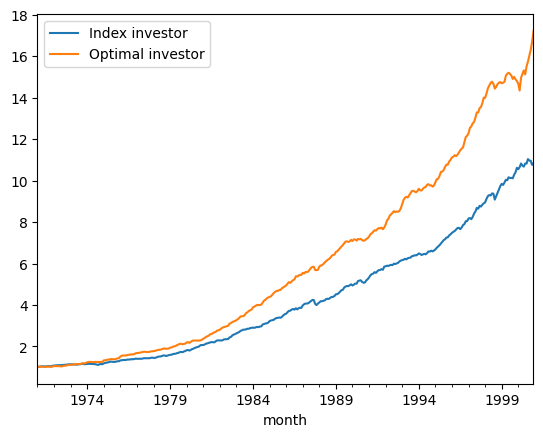

In [28]:
(1+investor_returns).cumprod().plot(legend=True,label="Index investor");
(1+new_investor_returns).cumprod().plot(legend=True,label="Optimal investor");